# Climate Coding Challenge

Climate change is impacting the way people live around the world



## Set up

To get started on this notebook, you’ll need to restore any variables
from previous notebooks to your workspace. To save time and memory, make
sure to specify which variables you want to load.

In [19]:
# import stored variables
%store -r

In [20]:
#import libraries
import holoviews as hv ### save interactive plots
import hvplot.pandas ### make interactive plots
import pandas as pd
import os 
import matplotlib.pyplot as plt
import os 


In [28]:
#Check stored variables 

plot_yearly_avg
elpaso_df
yearly_avg

,Temp_F,Temp_C
Date,,
1895-12-31,66.0,18.888889
1896-12-31,67.3,19.611111
1897-12-31,65.8,18.777778
1898-12-31,68.4,20.222222
1899-12-31,68.5,20.277778
...,...,...
2022-12-31,69.5,20.833333
2023-12-31,69.7,20.944444
2024-12-31,71.2,21.777778


You will also need to import any libraries you are using in this
notebook, since they won’t carry over from the previous notebook:

## Step 5: Quantify how fast the climate is changing with a trend line

Global climate change causes different effects in different places when
we zoom in to a local area. However, you probably noticed when you
looked at mean annual temperatures over time that they were rising. We
can use a technique called **Linear Ordinary Least Squares (OLS)
Regression** to determine how quickly temperatures are rising on
average.

Before we get started, it’s important to consider that OLS regression is
not always the right technique, because it makes some important
assumptions about our data:

**Random error**  
Variation in temperature can be caused by many things beyond global
climate change. For example, temperatures often vary with patterns of
ocean surface temperatures (*teleconnections*), the most famous of which
are El Niño and La Niña. By using a linear OLS regression, we’re
assuming that all the variation in temperature except for climate change
is random.

**Normally distributed data**  
If you have taken a statistics class, you probably learned a lot about
the normal, or Gaussian distribution. For right now, what you need to
know is that OLS regression is useful for identifying trends in average
temperature, but wouldn’t be appropriate for looking at trends in daily
precipitation (because most days have zero precipitation), or at maximum
or minimum annual temperatures (because these are extreme values, and
the normal distribution tends to underestimate the likelihood of large
events).

**Linearity**  
We’re assuming that temperatures are increasing or decreasing at a
constant rate over time. We wouldn’t be able to look at rates that
change over time. For example, many locations in the Arctic remained the
same temperature for much longer than the rest of the world, because ice
melt was absorbing all the extra heat. Linear OLS regression wouldn’t be
able to identify when the temperature rise began on its own.

**Stationarity**  
We’re assuming that variation in temperature caused by things *other*
than global climate change (e.g. the random error) behaves the same over
time. For example, the linear OLS regression can’t take increased
variability from year to year into account, which is a common effect of
climate change. We often see “global weirding”, or more extreme head
*and* cold, in addition to overall increases. You can observe this most
easily by looking at your daily data again. Does it seem to be fanning
in or out over time?

It’s pretty rare to encounter a perfect statistical model where all the
assumptions are met, but you want to be on the lookout for serious
discrepancies, especially when making predictions. For example,
[ignoring assumptions about Gaussian error arguably led to the 2008
financial crash](https://www.wired.com/2009/02/wp-quant/).

### Reflect and Respond #3: Is linear OLS regression right for your data?
Take a look at your data. In the cell below, write a few sentences about ways your data does and does not meet the linear OLS regression assumptions.

### Assumption thoughts:

Random error: Though we assume that all error beyond climate change is random, as mentioned above there are other factors that may directly influence temperature change such as shifting teleconnections.

Stationarity: Data seems to be "fanning in" over time in Boulder's case. Yearly annual data has shown less extreme periods of cold, instead showing a trend of warming despite changing teleconnections throughout time, which in past years created large scale variation. In recent years (post 1980) ocean driven temperature trends still seem to exist, however these trends still exhibit warming, with lower cold extremes, and higher warm extremes. 

Linearity: There is a clear trend of warming seen from 1880-2020. However extreme shifts in ~1940 disturp the linear trend, and influence the regression, potentially leading a slightly steeper trendline slope than what would be present without those extreme periods.

Gaussian Distribution: The seen extremes ~1940 effect the normal distribution of the data, though likely not to a point where error is too large to accept the warming trend. There is also a gap in the data directly after shown extremes that if present, would likely influence the distribution as well. 

The following cell contains package imports that you will need to calculate and plot an OLS Linear trend line. Make sure to run the cell before moving on, and if you have any additional packages you would like to use, add them here later on:

In [22]:
### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt
### common statistical plots for tabular data
import seaborn as sns
### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try running a regression</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Adapt the sample code below to fit your variable names.</li>
<li>Check out your previous plot. Does it make sense to include all the
data when calculating a trend line? Be sure to select out data that
meets the OLS assumptions.</li>
</ol></div></div>

In [ ]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = yearly_avg.index.year.values.reshape(-1, 1)
### define dependent variable
dep_variable = yearly_avg['Temp_C']

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: 0.007832732420920455 degrees per year


### Step 5B: Plot your trend line

Trend lines are often used to help your audience understand and process
a time-series plot. In this case, we’ve chosen mean temperature values
rather than extremes, so we think OLS is an appropriate model to use to
show a trend.

> **Is it ok to plot a trend line even if OLS isn’t an appropriate
> model?**
>
> This is a tricky issue. When it comes to a trend line, choosing a
> model that is technically more appropriate may require much more
> complex code without resulting in a noticeably different trend line.
>
> We think an OLS trend line is an ok visual tool to indicate the
> approximate direction and size of a trend. If you are showing standard
> error, making predictions or inferences based on your model, or
> calculating probabilities (p-values) based on your model, or making
> statements about the statistical significance of a trend, we’d suggest
> reconsidering your choice of model.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try it:</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Add values for x (year) and y (temperature) to plot a regression
plot. You will have to select out the year from the index values, just
like you probably did when fitting your linear model above!</li>
<li>Label the axes of your plot with the <code>title</code>,
<code>xlabel</code>, and <code>ylabel</code> parameters. You can see how
to add the degree symbol in the example below. Make sure your labels
match what you’re plotting!</li>
<li>Can you figure out how to customize the colors and line style on your plot? Check out the <code>seaborn</code> <a
href="https://seaborn.pydata.org/">documentation</a> for ideas.</li>
</ol></div></div>

In [ ]:
# Get current working directory so you know where to save your figure
os.getcwd()

'/Users/davidwilcox/Desktop/01-climate-fall'

<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
/var/folders/hl/l52pw3jj3ggc13gqlmtsqw_w0000gn/T/ipykernel_66131/1389154609.py:15: SyntaxWarning: invalid escape sequence '\c'
  ylabel = 'Temperature ($^\circ$C)',


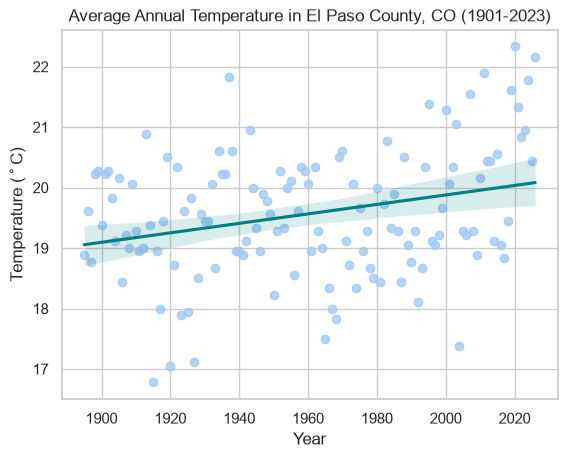

In [27]:
### plot data
# Change style using seaborn style, and pallete options.
# Change trendline color to stand out from scatter points.
sns.set_theme(style="whitegrid", palette="pastel")
ax = sns.regplot(
    x = yearly_avg.index.year, 
    y = yearly_avg['Temp_C'],
    line_kws = {'color': 'teal'}
)

### make labels
ax.set(
    title = 'Average Annual Temperature in El Paso County, CO (1901-2023)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)',
)

### save your plot
plt.savefig('/Users/davidwilcox/Desktop/01-climate-fall/ElPaso_ann_temp.jpeg')
### plot it
plt.show()

#Do seaborn styles to change color etc. 

### Reflect and Respond #4: Interpret the trend
1.  Create a new Markdown cell below this one.
2. Write a plot headline. Your headline should **interpret** your plot, unlike a caption which neutrally
describes the image.
3. Is the climate changing? How much? Report the slope of your trend line.

### Anuual Temperature in Boulder, CO (1880-2020), shows clear trend of warming throughout time, despite El Nino-Southern Oscillation (ENSO) fluctuations. 

A consistent warming trend is shown through analysis of temperature data time-series. With a OLS regression analysis exhibiting a slope of 0.018095139055852492. Which communicates a warming trend of 0.018095139055852492 degrees per year. 